In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
import os
DATASET_PATH = "/content/drive/MyDrive/Diverse Fetal Head Images"
print(os.listdir(DATASET_PATH))

['Test-Dataset-Segmentation', 'SegmentationClass', 'Orginal_train_images_to_959_661']


In [8]:
!pip install -q segmentation-models-pytorch albumentations
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
print('PyTorch:', torch.__version__)
print('GPU available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 13.5 MB/s eta 0:00:00
PyTorch: 2.11.0+cu128
GPU available: True
GPU: Tesla T4


In [9]:
import os
IMAGES_DIR  = '/content/drive/MyDrive/Diverse Fetal Head Images/Orginal_train_images_to_959_661'
MASKS_DIR   = '/content/drive/MyDrive/Diverse Fetal Head Images/SegmentationClass'
CHECKPT_DIR = '/content/drive/MyDrive/unet_fetal_checkpoints'
os.makedirs(CHECKPT_DIR, exist_ok=True)
assert os.path.isdir(IMAGES_DIR), f'Images folder not found: {IMAGES_DIR}'
assert os.path.isdir(MASKS_DIR),  f'Masks folder not found: {MASKS_DIR}'
imgs  = sorted(os.listdir(IMAGES_DIR))
masks = sorted(os.listdir(MASKS_DIR))
print(f'Found {len(imgs)} images and {len(masks)} masks')
print('Sample images:', imgs[:3])
print('Sample masks :', masks[:3])

Found 999 images and 999 masks
Sample images: ['000_HC.png', '001_HC.png', '002_HC.png']
Sample masks : ['000_HC.png', '001_HC.png', '002_HC.png']


Sample 1 | unique values: [0 1]
Sample 2 | unique values: [0 1]
Sample 3 | unique values: [0 1]


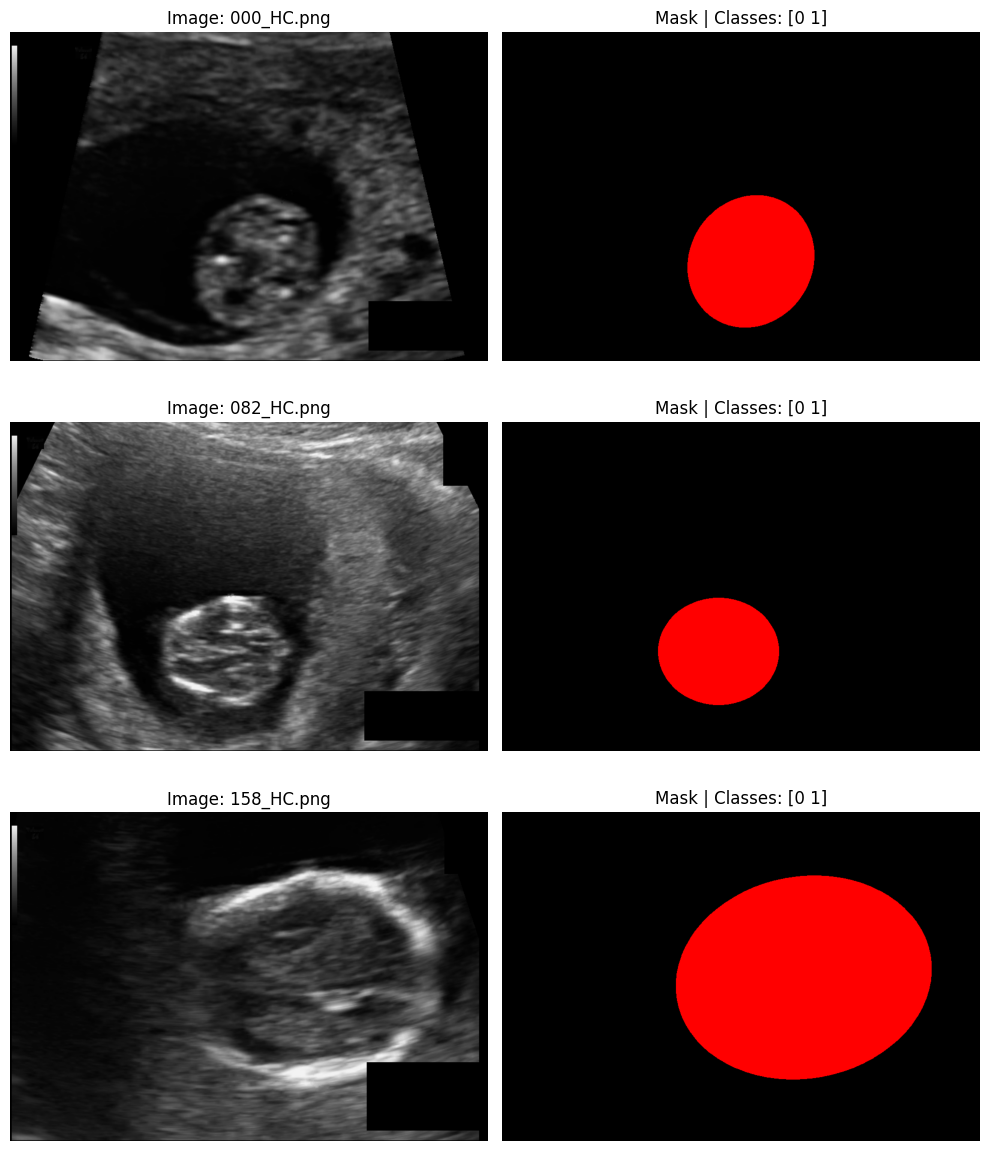

In [ ]:

NUM_CLASSES = 2
CLASS_COLORS = {
    0: (0,   0,   0),    # Black = Background
    1: (255, 0,   0),    # Red   = Fetal Head
}
def colorize_mask(mask):
    if mask.ndim == 3:
        mask = mask[:, :, 0]
    h, w = mask.shape
    color = np.zeros((h, w, 3), dtype=np.uint8)
    for cls, rgb in CLASS_COLORS.items():
        color[mask == cls] = rgb
    return color
fig, axes = plt.subplots(3, 2, figsize=(10, 12))
for i in range(3):
    img_path  = os.path.join(IMAGES_DIR, imgs[i*100])
    stem      = os.path.splitext(imgs[i*100])[0]
    mask_name = stem + '.png'
    mask_path = os.path.join(MASKS_DIR, mask_name)
    if not os.path.exists(mask_path):
        mask_path = os.path.join(MASKS_DIR, masks[i*100])
    img  = np.array(Image.open(img_path).convert('RGB'))
    mask = np.array(Image.open(mask_path))
    if mask.ndim == 3:
        mask = (mask[:, :, 0] > 127).astype(np.uint8)
    unique_classes = np.unique(mask)
    print(f'Sample {i+1} | unique values: {unique_classes}')
    axes[i,0].imshow(img)
    axes[i,0].set_title(f'Image: {imgs[i*100]}')
    axes[i,0].axis('off')
    axes[i,1].imshow(colorize_mask(mask))
    axes[i,1].set_title(f'Mask | Classes: {unique_classes}')
    axes[i,1].axis('off')
plt.tight_layout()
plt.show()

In [11]:
class FetalHeadDataset(Dataset):
    def __init__(self, image_paths, mask_paths, transform=None):
        self.image_paths = image_paths
        self.mask_paths  = mask_paths
        self.transform   = transform
    def __len__(self):
        return len(self.image_paths)
    def __getitem__(self, idx):
        img  = np.array(Image.open(self.image_paths[idx]).convert('RGB'))
        mask = np.array(Image.open(self.mask_paths[idx]))
        if mask.ndim == 3:
            mask = (mask[:, :, 0] > 127).astype(np.uint8)
        else:
            mask = (mask > 127).astype(np.uint8)
        if self.transform:
            augmented = self.transform(image=img, mask=mask)
            img  = augmented['image']
            mask = augmented['mask']
        return img, mask.long()

In [12]:
def find_mask_for_image(img_name, masks_dir, mask_list):
    stem = os.path.splitext(img_name)[0]
    for ext in ['.png', '.jpg', '.jpeg', '.bmp']:
        candidate = stem + ext
        if candidate in mask_list:
            return os.path.join(masks_dir, candidate)
    return None
image_files = sorted([f for f in os.listdir(IMAGES_DIR)
                       if f.lower().endswith(('.png','.jpg','.jpeg','.bmp'))])
mask_files  = set(os.listdir(MASKS_DIR))
paired_images, paired_masks = [], []
for img_name in image_files:
    mask_path = find_mask_for_image(img_name, MASKS_DIR, mask_files)
    if mask_path:
        paired_images.append(os.path.join(IMAGES_DIR, img_name))
        paired_masks.append(mask_path)
print(f'Paired samples: {len(paired_images)}')
assert len(paired_images) > 0, 'No pairs found! Check your paths or file naming.'
train_imgs, val_imgs, train_masks, val_masks = train_test_split(
    paired_images, paired_masks, test_size=0.2, random_state=42
)
print(f'Train: {len(train_imgs)} | Val: {len(val_imgs)}')

Paired samples: 999
Train: 799 | Val: 200


In [13]:
IMG_SIZE   = 256
BATCH_SIZE = 8
train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.RandomRotate90(p=0.3),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=15, p=0.4),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.4),
    A.GaussNoise(p=0.2),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])
val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])
train_dataset = FetalHeadDataset(train_imgs, train_masks, transform=train_transform)
val_dataset   = FetalHeadDataset(val_imgs,   val_masks,   transform=val_transform)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
print(f'Image size: {IMG_SIZE}x{IMG_SIZE}')
print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')

Image size: 256x256
Train batches: 100 | Val batches: 25


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [14]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', DEVICE)
model = smp.Unet(
    encoder_name    = 'resnet34',
    encoder_weights = 'imagenet',
    in_channels     = 3,
    classes         = 1,
    activation      = None,
)
model = model.to(DEVICE)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {total_params:,}')

Using device: cuda


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

Trainable parameters: 24,436,369


In [15]:
bce_loss  = nn.BCEWithLogitsLoss()
dice_loss = smp.losses.DiceLoss(mode='binary')
def criterion(preds, targets):
    targets_f = targets.float().unsqueeze(1)   # (B, 1, H, W)
    return bce_loss(preds, targets_f) + dice_loss(preds, targets_f)
print('Binary loss ready.')

Binary loss ready.


In [16]:
def compute_metrics(preds, targets):
    preds    = torch.sigmoid(preds)
    preds_b  = (preds > 0.5).float().squeeze(1)   # (B, H, W)
    targets_f = targets.float()
    intersection = (preds_b * targets_f).sum().float()
    union        = preds_b.sum() + targets_f.sum()
    dice = (2 * intersection + 1e-6) / (union + 1e-6)
    iou  = (intersection + 1e-6) / (union - intersection + 1e-6)
    return iou.item(), dice.item()

In [17]:
optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr      = 3e-4,
    epochs      = 50,
    steps_per_epoch = len(train_loader),
    pct_start   = 0.1,   # 10% warmup
)
print('Optimizer and scheduler ready.')

Optimizer and scheduler ready.


In [18]:
NUM_EPOCHS   = 25
best_val_iou = 0.0
history      = {'train_loss': [], 'val_loss': [], 'val_iou': [], 'val_dice': []}
for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    train_loss = 0.0
    for images, masks in train_loader:
        images = images.to(DEVICE)
        masks  = masks.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)          # (B, 1, H, W)
        loss    = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        scheduler.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)
    model.eval()
    val_loss = 0.0
    val_ious, val_dices = [], []
    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(DEVICE)
            masks  = masks.to(DEVICE)
            outputs = model(images)
            loss    = criterion(outputs, masks)
            val_loss += loss.item()
            iou, dice = compute_metrics(outputs, masks)
            val_ious.append(iou)
            val_dices.append(dice)
    val_loss  /= len(val_loader)
    mean_iou   = np.mean(val_ious)
    mean_dice  = np.mean(val_dices)
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_iou'].append(mean_iou)
    history['val_dice'].append(mean_dice)
    if mean_iou > best_val_iou:
        best_val_iou = mean_iou
        torch.save(model.state_dict(), os.path.join(CHECKPT_DIR, 'best_unet.pth'))
        saved = ' Saved'
    else:
        saved = ''
    print(f'Epoch [{epoch:02d}/{NUM_EPOCHS}] '
          f'Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | '
          f'Val IoU: {mean_iou:.4f} | Val Dice: {mean_dice:.4f} {saved}')
print(f'\nBest Val IoU: {best_val_iou:.4f}')
print(f'Model saved to: {CHECKPT_DIR}/best_unet.pth')

Epoch [01/25] Train Loss: 0.9672 | Val Loss: 0.5655 | Val IoU: 0.8024 | Val Dice: 0.8900  Saved
Epoch [02/25] Train Loss: 0.4776 | Val Loss: 0.2978 | Val IoU: 0.9126 | Val Dice: 0.9542  Saved
Epoch [03/25] Train Loss: 0.2721 | Val Loss: 0.2385 | Val IoU: 0.8903 | Val Dice: 0.9418 
Epoch [04/25] Train Loss: 0.1717 | Val Loss: 0.1332 | Val IoU: 0.9372 | Val Dice: 0.9676  Saved
Epoch [05/25] Train Loss: 0.1442 | Val Loss: 0.1110 | Val IoU: 0.9361 | Val Dice: 0.9668 
Epoch [06/25] Train Loss: 0.1236 | Val Loss: 0.0931 | Val IoU: 0.9421 | Val Dice: 0.9702  Saved
Epoch [07/25] Train Loss: 0.1070 | Val Loss: 0.1019 | Val IoU: 0.9352 | Val Dice: 0.9663 
Epoch [08/25] Train Loss: 0.1125 | Val Loss: 0.0972 | Val IoU: 0.9362 | Val Dice: 0.9671 
Epoch [09/25] Train Loss: 0.0983 | Val Loss: 0.0737 | Val IoU: 0.9508 | Val Dice: 0.9748  Saved
Epoch [10/25] Train Loss: 0.0889 | Val Loss: 0.0752 | Val IoU: 0.9485 | Val Dice: 0.9735 
Epoch [11/25] Train Loss: 0.0852 | Val Loss: 0.0700 | Val IoU: 0.9514 

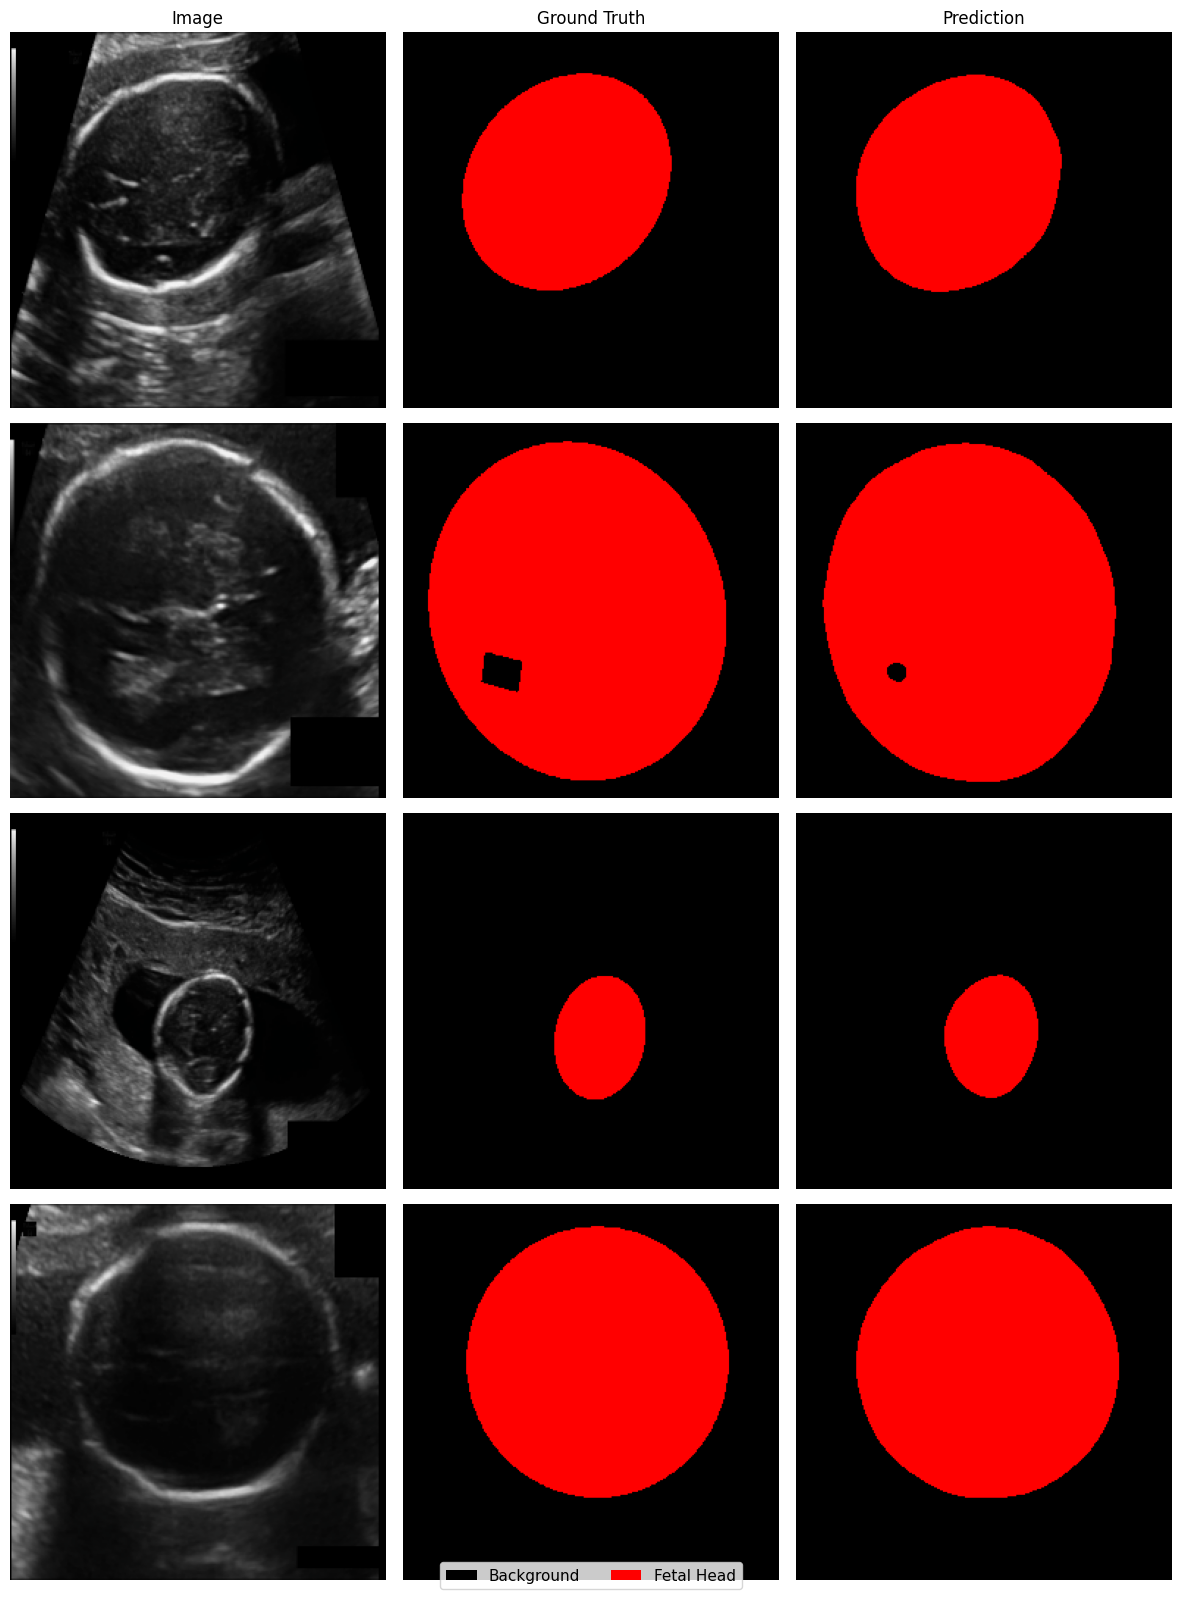

In [19]:
model.load_state_dict(torch.load(os.path.join(CHECKPT_DIR, 'best_unet.pth'), map_location=DEVICE))
model.eval()
mean_n = np.array([0.485, 0.456, 0.406])
std_n  = np.array([0.229, 0.224, 0.225])
def denormalize(tensor):
    img = tensor.cpu().numpy().transpose(1, 2, 0)
    return np.clip(img * std_n + mean_n, 0, 1)
fig, axes = plt.subplots(4, 3, figsize=(12, 16))
axes[0,0].set_title('Image')
axes[0,1].set_title('Ground Truth')
axes[0,2].set_title('Prediction')
sample_ds = FetalHeadDataset(val_imgs[:4], val_masks[:4], transform=val_transform)
for i in range(4):
    img_t, mask_t = sample_ds[i]
    with torch.no_grad():
        pred = torch.sigmoid(
            model(img_t.unsqueeze(0).to(DEVICE))
        ).squeeze().cpu().numpy()
        pred = (pred > 0.5).astype(np.uint8)
    gt_color   = np.zeros((*mask_t.shape, 3), dtype=np.uint8)
    pred_color = np.zeros((*pred.shape,   3), dtype=np.uint8)
    gt_color  [mask_t.numpy() == 1] = (255, 0, 0)
    pred_color[pred            == 1] = (255, 0, 0)
    axes[i,0].imshow(denormalize(img_t))
    axes[i,0].axis('off')
    axes[i,1].imshow(gt_color)
    axes[i,1].axis('off')
    axes[i,2].imshow(pred_color)
    axes[i,2].axis('off')
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='black', label='Background'),
    Patch(facecolor='red',   label='Fetal Head'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=2, fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(CHECKPT_DIR, 'final_predictions.png'), dpi=100)
plt.show()